# 11 - Baseline & Full Model Comparison

Consolidates the baseline and all nine models into one comparison, all evaluated on the same validation set:

- **Baseline:** rule based historical frequency classifier
- **Linear/margin based:** Logistic Regression, SVM (Linear)
- **Deep learning:** Neural Network (PyTorch)
- **Boosting family:** AdaBoost → Gradient Boosting (sklearn) → XGBoost → LightGBM → CatBoost, roughly in order of historical development
- **Other ensemble:** Random Forest

**Reminder:** everything here is validation set performance. The test set remains completely untouched until Stage 7 opens it exactly once for final evaluation of whichever model this comparison points toward.


## Load all metrics files

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

metrics_files = {
    'Rule-based baseline': '../../../data/processed/metrics_baseline.json',
    'Logistic Regression': '../../../data/processed/metrics_logreg.json',
    'SVM (Linear)': '../../../data/processed/metrics_svm.json',
    'Neural Network': '../../../data/processed/metrics_nn.json',
    'AdaBoost': '../../../data/processed/metrics_adaboost.json',
    'Gradient Boosting': '../../../data/processed/metrics_gb.json',
    'Random Forest': '../../../data/processed/metrics_rf.json',
    'XGBoost': '../../../data/processed/metrics_xgb.json',
    'LightGBM': '../../../data/processed/metrics_lightgbm.json',
    'CatBoost': '../../../data/processed/metrics_catboost.json',
}

all_metrics = []
for name, path in metrics_files.items():
    with open(path) as f:
        all_metrics.append(json.load(f))

comparison_df = pd.DataFrame(all_metrics).set_index('model')
comparison_df = comparison_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].round(4)
comparison_df.sort_values('recall', ascending=False)


,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.6172,0.7924,0.6939,0.7580,0.8234
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
Neural Network (PyTorch),0.5857,0.8458,0.6921,0.7653,0.8301
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053
SVM (Linear),0.5618,0.8394,0.6731,0.7392,0.8102
Logistic Regression,0.5543,0.8379,0.6672,0.7394,0.8105


## Visual comparison - grouped bar chart across all metrics

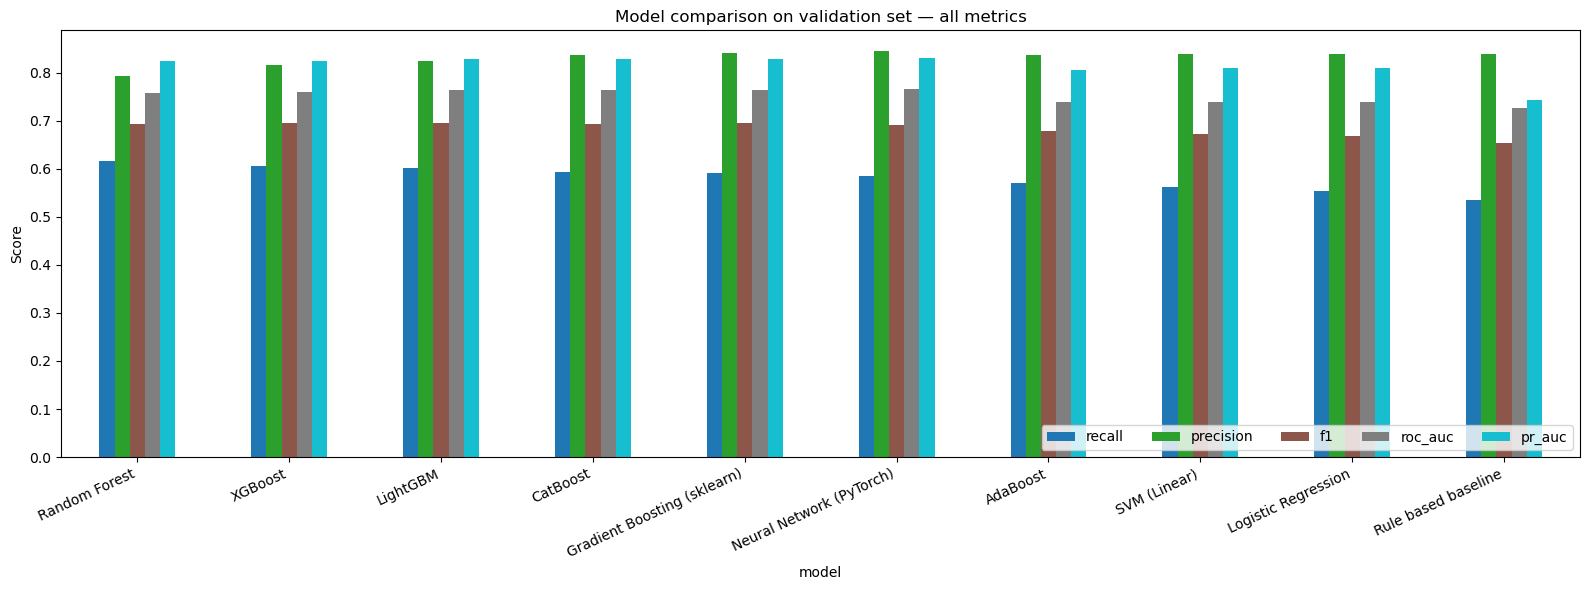

In [2]:
comparison_df.sort_values('recall', ascending=False).plot(kind='bar', figsize=(16, 6), colormap='tab10')
plt.title('Model comparison on validation set — all metrics')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower right', ncol=5)
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()


## Heatmap view - quick visual ranking across models and metrics

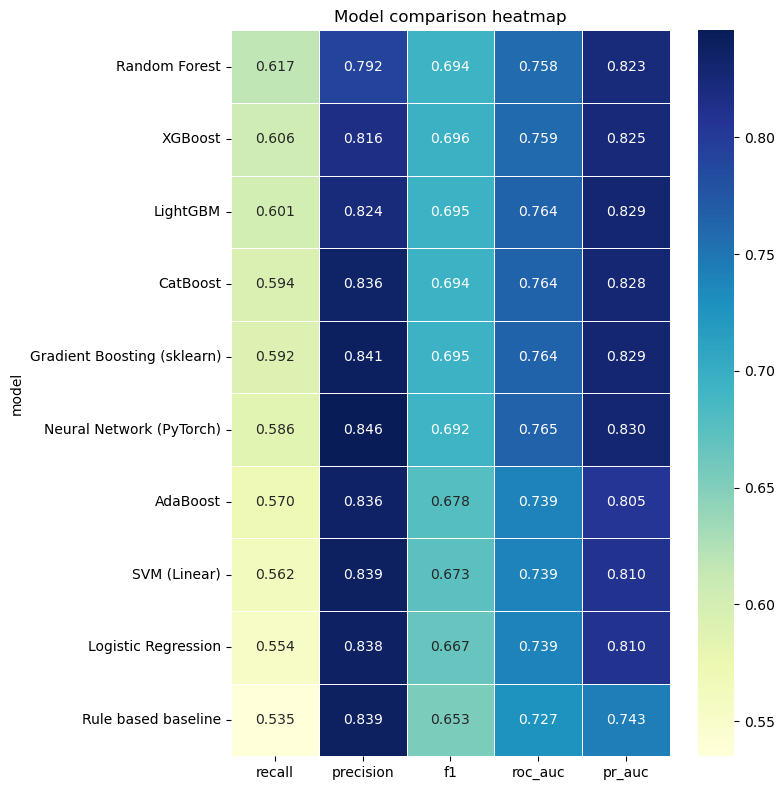

In [3]:
plt.figure(figsize=(8, 8))
sns.heatmap(comparison_df.sort_values('recall', ascending=False), annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Model comparison heatmap')
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## Boosting family sub comparison

Since five of these models are boosting variants, a focused view of just that family helps tell the "evolution of boosting" story clearly, separate from the full 10 model comparison above.


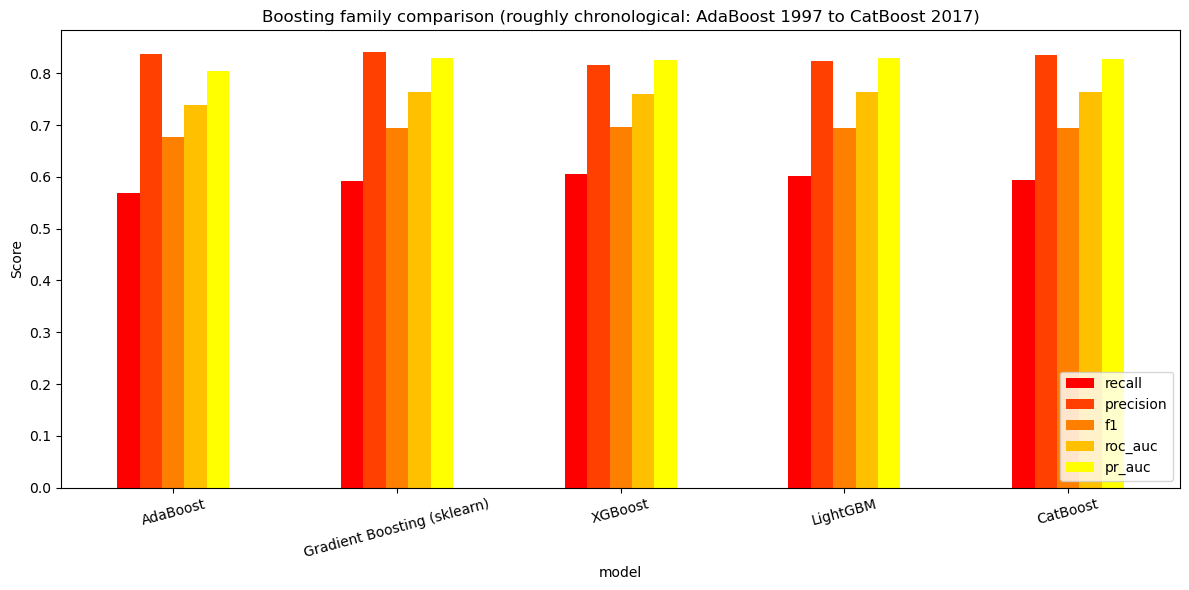

,recall,precision,f1,roc_auc,pr_auc
model,,,,,
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284


In [6]:
boosting_family = ['AdaBoost', 'Gradient Boosting (sklearn)', 'XGBoost', 'LightGBM', 'CatBoost']
boosting_df = comparison_df.loc[[m for m in boosting_family if m in comparison_df.index]]

boosting_df.plot(kind='bar', figsize=(12, 6), colormap='autumn')
plt.title('Boosting family comparison (roughly chronological: AdaBoost 1997 to CatBoost 2017)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../../../reports/figures/boosting_family_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

boosting_df


**What we found (10 of 12 models, Voting and Stacking still to come):**

**Overall ranking by Recall (primary metric):** Random Forest leads (0.6172), followed by XGBoost (0.6062), LightGBM (0.6011), CatBoost (0.5936), Gradient Boosting (0.5917), Neural Network (0.5857), AdaBoost (0.5695), SVM (0.5618), Logistic Regression (0.5543), and the baseline last (0.5349). **The gap from baseline to the best model is 8.2 points of Recall**, confirming real, meaningful improvement across the model development stage.

**The boosting family does not show a clean "newer is better" progression, and that's the single most important finding from this whole comparison.** AdaBoost genuinely underperforms (Recall 0.5695, ROC-AUC 0.7393, closer to the linear models than the tree ensembles). But Gradient Boosting (sklearn), the "obsolete" predecessor to XGBoost, is statistically indistinguishable from XGBoost, LightGBM, and CatBoost on every metric, F1 across all four sits in a tight 0.6942 to 0.6956 band. **The real evolution in boosting wasn't accuracy, it was AdaBoost → Gradient Boosting (a genuine methodological improvement) and then Gradient Boosting → the modern three libraries (primarily a training-speed and engineering improvement, not an accuracy one, on this dataset).** This is a more precise, defensible story than the "boosting kept getting better" narrative we started with, and it's worth stating exactly this way in the final report, since it shows genuine critical engagement with the results rather than confirming an assumption.

**The Random Forest vs. Neural Network tension from earlier notebooks is now resolved by looking at the full picture:** Random Forest leads Recall, but the Neural Network leads ROC-AUC (0.7653), PR-AUC (0.8301), and Precision (0.8458), the best ranking-quality model overall. Since our stated priority is Recall specifically (due to cost-sensitivity, not imbalance), Random Forest is the stronger candidate on the metric that matters most for the business problem, but the Neural Network's superior ranking quality means it could catch up or overtake once Stage 8 tunes the classification threshold away from the default 0.5, a high-AUC model has more headroom to trade some Precision for Recall via threshold adjustment than a lower-AUC model does. **Both Random Forest and the Neural Network should be carried into Stage 8's tuning as genuine candidates, not just Random Forest by default.** XGBoost, LightGBM, and CatBoost, being statistically tied with each other and close behind Random Forest on Recall, remain reasonable candidates too, though the boosting-family finding above suggests picking any one of the three is arbitrary rather than a meaningfully justified choice.

**SVM and Logistic Regression confirmed functionally identical** (Notebook 05's convergence fix), no reason to carry both forward as distinct options.

